# Task 2: Generative Models (VAE + DCGAN) on Tiny ImageNet
Implement and compare a Convolutional VAE and DCGAN for generating synthetic 64×64 RGB images.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
import matplotlib.pyplot as plt
import numpy as np
import os
import shutil
from sklearn.manifold import TSNE
from skimage.metrics import structural_similarity as ssim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


## 1. Load Tiny ImageNet

In [3]:
# Download Tiny ImageNet (requires: pip install kagglehub)
import kagglehub

data_root = kagglehub.dataset_download("akash2sharma/tiny-imagenet")
print(f"Downloaded to: {data_root}")

# Locate the directory containing train/ and val/
tiny_dir = data_root
for root, dirs, files in os.walk(data_root):
    if 'train' in dirs and 'val' in dirs:
        tiny_dir = root
        break
print(f"Tiny ImageNet root: {tiny_dir}")

100%|██████████| 474M/474M [00:11<00:00, 43.7MB/s] 

Extracting files...


Downloaded to: C:\Users\kingj2\.cache\kagglehub\datasets\akash2sharma\tiny-imagenet\versions\1
Tiny ImageNet root: C:\Users\kingj2\.cache\kagglehub\datasets\akash2sharma\tiny-imagenet\versions\1\tiny-imagenet-200


In [4]:
# Reorganize val folder into ImageFolder-compatible structure
val_dir = os.path.join(tiny_dir, 'val')
val_img_dir = os.path.join(val_dir, 'images')
val_annotations = os.path.join(val_dir, 'val_annotations.txt')

if os.path.exists(val_img_dir) and os.path.isdir(val_img_dir):
    print("Reorganizing val folder...")
    with open(val_annotations, 'r') as f:
        for line in f:
            parts = line.strip().split('\t')
            fname, class_name = parts[0], parts[1]
            class_dir = os.path.join(val_dir, class_name)
            os.makedirs(class_dir, exist_ok=True)
            src = os.path.join(val_img_dir, fname)
            dst = os.path.join(class_dir, fname)
            if os.path.exists(src):
                shutil.move(src, dst)
    if os.path.exists(val_img_dir) and not os.listdir(val_img_dir):
        os.rmdir(val_img_dir)
    print("Val folder reorganized.")
else:
    print("Val folder already organized or images/ not found.")

# Transforms
transform_vae = transforms.Compose([
    transforms.Resize(64),
    transforms.CenterCrop(64),
    transforms.ToTensor(),
])

transform_gan = transforms.Compose([
    transforms.Resize(64),
    transforms.CenterCrop(64),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])

train_dir = os.path.join(tiny_dir, 'train')

# VAE datasets ([0,1] range for Sigmoid output)
train_dataset_vae = datasets.ImageFolder(train_dir, transform=transform_vae)
val_dataset_vae = datasets.ImageFolder(val_dir, transform=transform_vae)

# GAN dataset ([-1,1] range for Tanh output)
train_dataset_gan = datasets.ImageFolder(train_dir, transform=transform_gan)

# Optional: use 50% subset for faster training
USE_SUBSET = False
if USE_SUBSET:
    n = len(train_dataset_vae)
    indices = np.random.RandomState(42).choice(n, n // 2, replace=False).tolist()
    train_dataset_vae = Subset(train_dataset_vae, indices)
    train_dataset_gan = Subset(train_dataset_gan, indices)

batch_size = 128
train_loader_vae = DataLoader(train_dataset_vae, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader_vae = DataLoader(val_dataset_vae, batch_size=batch_size, shuffle=False, num_workers=2)
train_loader_gan = DataLoader(train_dataset_gan, batch_size=batch_size, shuffle=True, num_workers=2)

print(f"VAE training samples: {len(train_dataset_vae)}")
print(f"VAE validation samples: {len(val_dataset_vae)}")
print(f"GAN training samples: {len(train_dataset_gan)}")

Reorganizing val folder...
Val folder reorganized.
VAE training samples: 100000
VAE validation samples: 10000
GAN training samples: 100000


### Display example images

In [ ]:
class_names_tiny = val_dataset_vae.classes  # synset IDs, e.g. 'n01443537'

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i in range(10):
    img, label = val_dataset_vae[i * 100]
    ax = axes[i // 5, i % 5]
    ax.imshow(img.permute(1, 2, 0).numpy())
    ax.set_title(class_names_tiny[label], fontsize=8)
    ax.axis('off')
plt.suptitle('Tiny ImageNet Example Images')
plt.tight_layout()
plt.show()

## 2. Convolutional Variational Autoencoder (VAE)

In [6]:
class ConvVAE(nn.Module):
    def __init__(self, latent_dim=256):
        super().__init__()
        self.latent_dim = latent_dim

        # Encoder: 3x64x64 -> 256x4x4 -> mu, logvar
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, 4, 2, 1),    # -> 32x32x32
            nn.BatchNorm2d(32),
            nn.LeakyReLU(0.2),
            nn.Conv2d(32, 64, 4, 2, 1),   # -> 64x16x16
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2),
            nn.Conv2d(64, 128, 4, 2, 1),  # -> 128x8x8
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2),
            nn.Conv2d(128, 256, 4, 2, 1), # -> 256x4x4
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2),
        )
        self.fc_mu = nn.Linear(256 * 4 * 4, latent_dim)
        self.fc_logvar = nn.Linear(256 * 4 * 4, latent_dim)

        # Decoder: latent_dim -> 3x64x64
        self.decoder_fc = nn.Linear(latent_dim, 256 * 4 * 4)
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(256, 128, 4, 2, 1), # -> 128x8x8
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.ConvTranspose2d(128, 64, 4, 2, 1),  # -> 64x16x16
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 4, 2, 1),   # -> 32x32x32
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 3, 4, 2, 1),    # -> 3x64x64
            nn.Sigmoid(),
        )

    def encode(self, x):
        h = self.encoder(x)
        h = h.view(h.size(0), -1)
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h = self.decoder_fc(z)
        h = h.view(h.size(0), 256, 4, 4)
        return self.decoder(h)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        x_recon = self.decode(z)
        return x_recon, mu, logvar


def vae_loss_fn(x_recon, x, mu, logvar):
    recon_loss = F.mse_loss(x_recon, x, reduction='sum') / x.size(0)
    kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp()) / x.size(0)
    return recon_loss + kl_loss, recon_loss, kl_loss


vae = ConvVAE(latent_dim=256).to(device)
print(vae)
print(f"\nTotal parameters: {sum(p.numel() for p in vae.parameters()):,}")

ConvVAE(
  (encoder): Sequential(
    (0): Conv2d(3, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.2)
    (3): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): LeakyReLU(negative_slope=0.2)
    (6): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (7): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): LeakyReLU(negative_slope=0.2)
    (9): Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (10): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): LeakyReLU(negative_slope=0.2)
  )
  (fc_mu): Linear(in_features=4096, out_features=256, bias=True)
  (fc_logvar): Linear(in_features=4096, out_features=256, bias=True)
  (decoder

### Train the VAE

In [ ]:
vae_optimizer = optim.Adam(vae.parameters(), lr=1e-3)
vae_epochs = 30

vae_train_losses = []
vae_val_losses = []

for epoch in range(vae_epochs):
    # Training
    vae.train()
    running_loss = 0.0
    for images, _ in train_loader_vae:
        images = images.to(device)
        x_recon, mu, logvar = vae(images)
        loss, _, _ = vae_loss_fn(x_recon, images, mu, logvar)
        vae_optimizer.zero_grad()
        loss.backward()
        vae_optimizer.step()
        running_loss += loss.item()
    train_loss = running_loss / len(train_loader_vae)
    vae_train_losses.append(train_loss)

    # Validation
    vae.eval()
    running_loss = 0.0
    with torch.no_grad():
        for images, _ in val_loader_vae:
            images = images.to(device)
            x_recon, mu, logvar = vae(images)
            loss, _, _ = vae_loss_fn(x_recon, images, mu, logvar)
            running_loss += loss.item()
    val_loss = running_loss / len(val_loader_vae)
    vae_val_losses.append(val_loss)

    print(f"Epoch [{epoch+1}/{vae_epochs}] Train: {train_loss:.4f} | Val: {val_loss:.4f}")

torch.save(vae.state_dict(), 'vae_tinyimagenet.pth')
print("VAE saved to vae_tinyimagenet.pth")

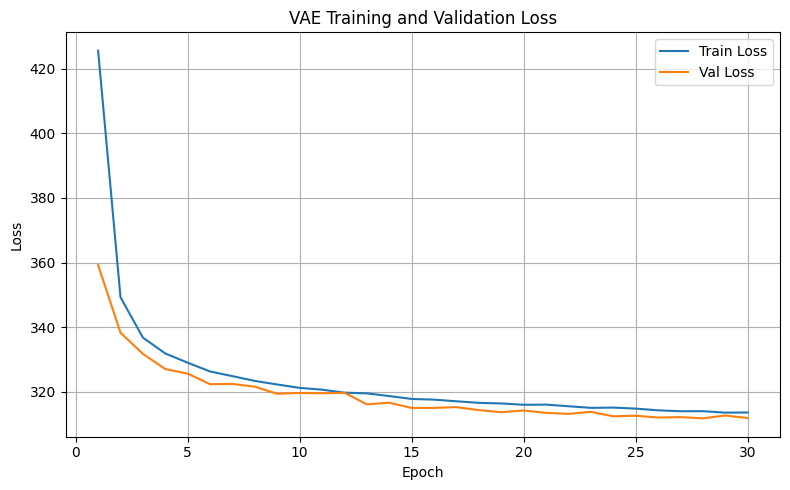

In [8]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, vae_epochs + 1), vae_train_losses, label='Train Loss')
plt.plot(range(1, vae_epochs + 1), vae_val_losses, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('VAE Training and Validation Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### VAE Reconstruction Quality

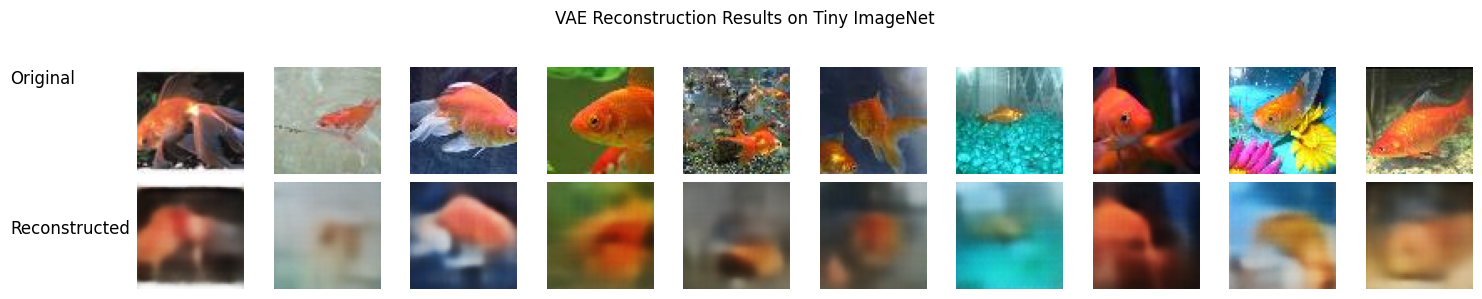

In [22]:
vae.eval()
images, labels = next(iter(val_loader_vae))
images = images.to(device)

with torch.no_grad():
    x_recon, _, _ = vae(images)

imgs_np = images.cpu().numpy()
recon_np = x_recon.cpu().numpy()

n = 10
fig, axes = plt.subplots(2, n, figsize=(15, 3))
for i in range(n):
    axes[0, i].imshow(np.transpose(imgs_np[i], (1, 2, 0)))
    axes[0, i].axis('off')
    axes[1, i].imshow(np.clip(np.transpose(recon_np[i], (1, 2, 0)), 0, 1))
    axes[1, i].axis('off')
fig.text(0.01, 0.75, 'Original', fontsize=12, va='center', ha='left')
fig.text(0.01, 0.25, 'Reconstructed', fontsize=12, va='center', ha='left')
plt.suptitle('VAE Reconstruction Results on Tiny ImageNet')
plt.tight_layout(rect=[0.08, 0, 1, 0.95])
plt.show()

## 3. Deep Convolutional GAN (DCGAN)

In [10]:
latent_dim_gan = 100


def weights_init(m):
    if isinstance(m, (nn.Conv2d, nn.ConvTranspose2d)):
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif isinstance(m, nn.BatchNorm2d):
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)


class Generator(nn.Module):
    def __init__(self, latent_dim=100):
        super().__init__()
        self.fc = nn.Linear(latent_dim, 256 * 4 * 4)
        self.main = nn.Sequential(
            nn.ConvTranspose2d(256, 128, 4, 2, 1),  # -> 128x8x8
            nn.BatchNorm2d(128),
            nn.ReLU(True),
            nn.ConvTranspose2d(128, 64, 4, 2, 1),   # -> 64x16x16
            nn.BatchNorm2d(64),
            nn.ReLU(True),
            nn.ConvTranspose2d(64, 32, 4, 2, 1),    # -> 32x32x32
            nn.BatchNorm2d(32),
            nn.ReLU(True),
            nn.ConvTranspose2d(32, 3, 4, 2, 1),     # -> 3x64x64
            nn.Tanh(),
        )

    def forward(self, z):
        h = self.fc(z)
        h = h.view(h.size(0), 256, 4, 4)
        return self.main(h)


class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 4, 2, 1),               # -> 32x32x32
            nn.LeakyReLU(0.2),
            nn.Conv2d(32, 64, 4, 2, 1),              # -> 64x16x16
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2),
            nn.Conv2d(64, 128, 4, 2, 1),             # -> 128x8x8
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2),
            nn.Conv2d(128, 256, 4, 2, 1),            # -> 256x4x4
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 4 * 4, 1),
        )

    def forward(self, x):
        feat = self.features(x)
        return self.classifier(feat)

    def extract_features(self, x):
        return self.features(x).view(x.size(0), -1)


netG = Generator(latent_dim_gan).to(device)
netD = Discriminator().to(device)
netG.apply(weights_init)
netD.apply(weights_init)

print("Generator:")
print(netG)
print(f"\nGenerator parameters: {sum(p.numel() for p in netG.parameters()):,}")
print(f"\nDiscriminator:")
print(netD)
print(f"\nDiscriminator parameters: {sum(p.numel() for p in netD.parameters()):,}")

Generator:
Generator(
  (fc): Linear(in_features=100, out_features=4096, bias=True)
  (main): Sequential(
    (0): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): ConvTranspose2d(64, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (7): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU(inplace=True)
    (9): ConvTranspose2d(32, 3, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (10): Tanh()
  )
)

Generator parameters: 1,104,035

Discriminator:
Discriminator(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): LeakyReL

### Train the DCGAN

In [ ]:
criterion_gan = nn.BCEWithLogitsLoss()
optimizerD = optim.Adam(netD.parameters(), lr=2e-4, betas=(0.5, 0.999))
optimizerG = optim.Adam(netG.parameters(), lr=2e-4, betas=(0.5, 0.999))
gan_epochs = 30

g_losses = []
d_losses = []

fixed_noise = torch.randn(64, latent_dim_gan, device=device)

for epoch in range(gan_epochs):
    netG.train()
    netD.train()
    epoch_g_loss = 0.0
    epoch_d_loss = 0.0
    num_batches = 0

    for real_images, _ in train_loader_gan:
        bs = real_images.size(0)
        real_images = real_images.to(device)

        real_label = torch.ones(bs, 1, device=device)
        fake_label = torch.zeros(bs, 1, device=device)

        # --- Train Discriminator ---
        netD.zero_grad()
        output_real = netD(real_images)
        loss_d_real = criterion_gan(output_real, real_label)

        noise = torch.randn(bs, latent_dim_gan, device=device)
        fake_images = netG(noise)
        output_fake = netD(fake_images.detach())
        loss_d_fake = criterion_gan(output_fake, fake_label)

        loss_d = loss_d_real + loss_d_fake
        loss_d.backward()
        optimizerD.step()

        # --- Train Generator ---
        netG.zero_grad()
        output_fake = netD(fake_images)
        loss_g = criterion_gan(output_fake, real_label)
        loss_g.backward()
        optimizerG.step()

        epoch_g_loss += loss_g.item()
        epoch_d_loss += loss_d.item()
        num_batches += 1

    avg_g = epoch_g_loss / num_batches
    avg_d = epoch_d_loss / num_batches
    g_losses.append(avg_g)
    d_losses.append(avg_d)

    print(f"Epoch [{epoch+1}/{gan_epochs}] D Loss: {avg_d:.4f} | G Loss: {avg_g:.4f}")

torch.save(netG.state_dict(), 'dcgan_generator_tinyimagenet.pth')
torch.save(netD.state_dict(), 'dcgan_discriminator_tinyimagenet.pth')
print("DCGAN saved to dcgan_generator_tinyimagenet.pth and dcgan_discriminator_tinyimagenet.pth")

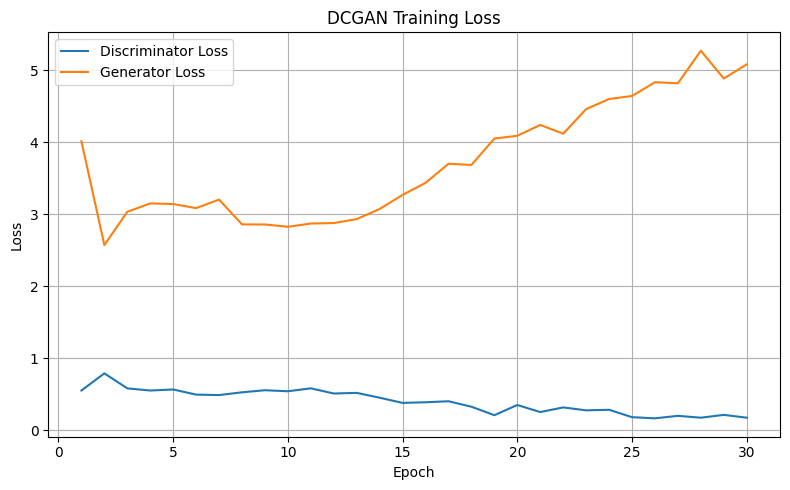

In [12]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, gan_epochs + 1), d_losses, label='Discriminator Loss')
plt.plot(range(1, gan_epochs + 1), g_losses, label='Generator Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('DCGAN Training Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## 4. Generate and Evaluate Synthetic Images

### Qualitative: Generated Image Grids

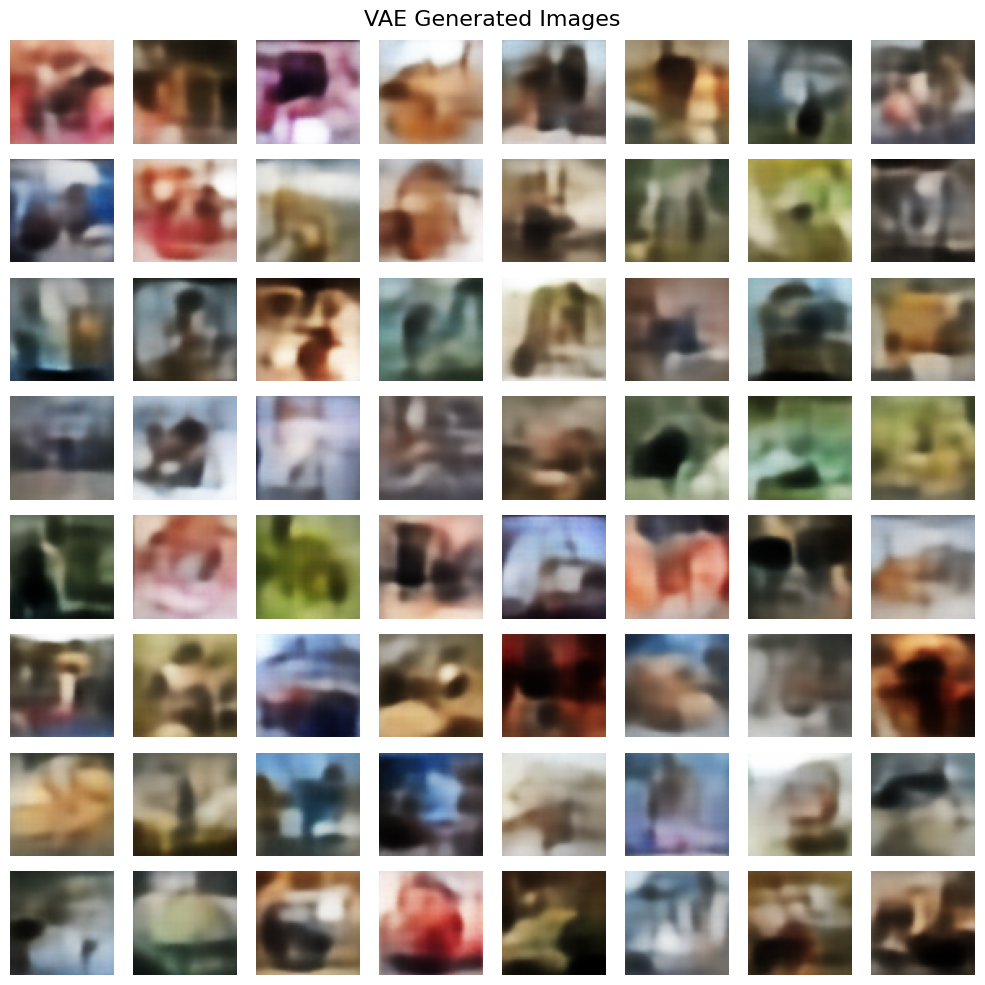

In [13]:
vae.eval()
with torch.no_grad():
    z = torch.randn(64, 256).to(device)
    generated_vae = vae.decode(z).cpu()

fig, axes = plt.subplots(8, 8, figsize=(10, 10))
for i in range(64):
    ax = axes[i // 8, i % 8]
    img = generated_vae[i].permute(1, 2, 0).numpy()
    img = np.clip(img, 0, 1)
    ax.imshow(img)
    ax.axis('off')
plt.suptitle('VAE Generated Images', fontsize=16)
plt.tight_layout()
plt.show()

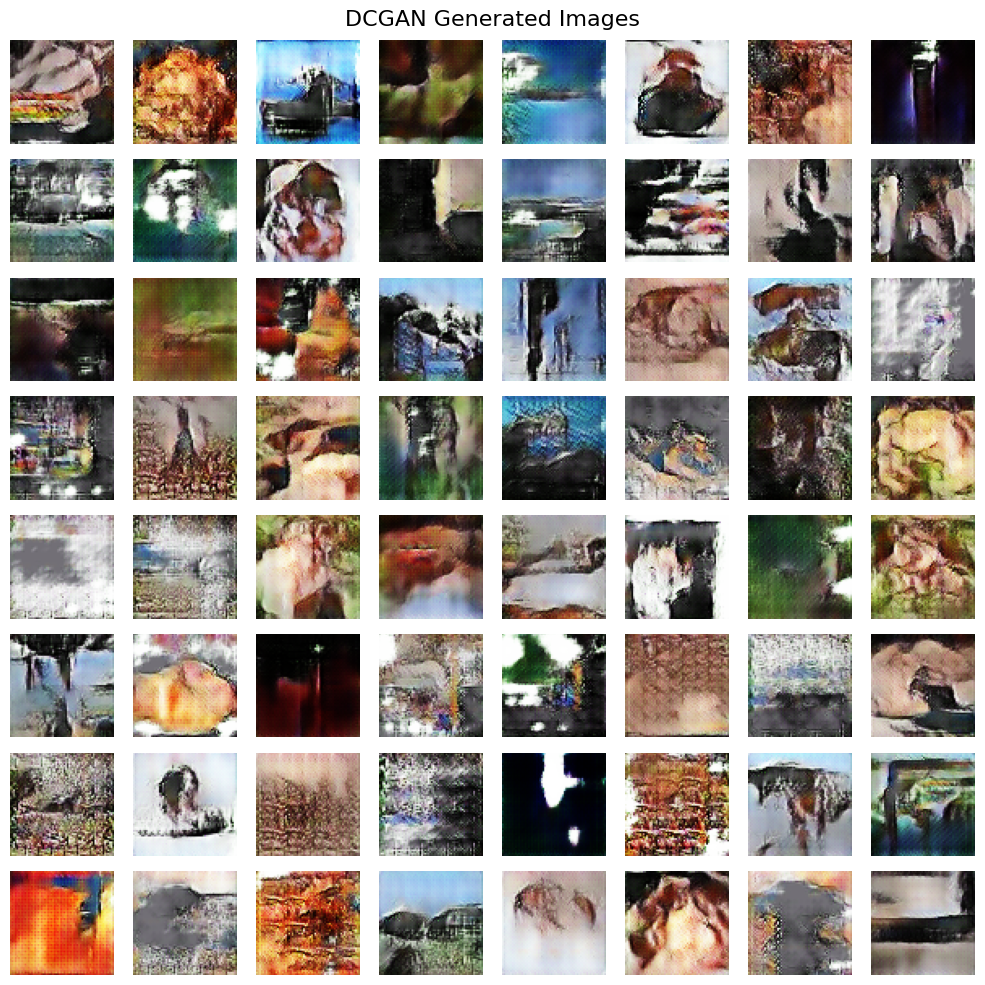

In [14]:
netG.eval()
with torch.no_grad():
    generated_gan = netG(fixed_noise).cpu()

fig, axes = plt.subplots(8, 8, figsize=(10, 10))
for i in range(64):
    ax = axes[i // 8, i % 8]
    img = generated_gan[i].permute(1, 2, 0).numpy()
    img = img * 0.5 + 0.5  # Denormalize [-1,1] -> [0,1]
    img = np.clip(img, 0, 1)
    ax.imshow(img)
    ax.axis('off')
plt.suptitle('DCGAN Generated Images', fontsize=16)
plt.tight_layout()
plt.show()

### Quantitative Evaluation — MSE and SSIM

In [15]:
# --- VAE Reconstruction MSE and SSIM on validation set ---
vae.eval()
mse_scores_vae = []
ssim_scores_vae = []

with torch.no_grad():
    for images, _ in val_loader_vae:
        images = images.to(device)
        x_recon, _, _ = vae(images)
        imgs_np = images.cpu().numpy()
        recon_np = x_recon.cpu().numpy()
        for i in range(imgs_np.shape[0]):
            orig = np.transpose(imgs_np[i], (1, 2, 0))
            recon = np.clip(np.transpose(recon_np[i], (1, 2, 0)), 0, 1)
            mse_scores_vae.append(np.mean((orig - recon) ** 2))
            ssim_scores_vae.append(ssim(orig, recon, data_range=1.0, channel_axis=2))

print("=== VAE Reconstruction Metrics ===")
print(f"MSE:  {np.mean(mse_scores_vae):.6f} (+/- {np.std(mse_scores_vae):.6f})")
print(f"SSIM: {np.mean(ssim_scores_vae):.4f} (+/- {np.std(ssim_scores_vae):.4f})")

# --- Compare generated images from both models to nearest real images ---
real_images_sample = []
for images, _ in val_loader_vae:
    real_images_sample.append(images.numpy())
    if len(real_images_sample) * batch_size >= 500:
        break
real_images_sample = np.concatenate(real_images_sample)[:500]


def evaluate_generated(generated_imgs, real_imgs, n_compare=100):
    """Compare each generated image to its nearest real image by MSE."""
    mse_list, ssim_list = [], []
    for i in range(len(generated_imgs)):
        gen = np.transpose(generated_imgs[i], (1, 2, 0))
        best_mse = float('inf')
        best_ssim = 0
        subset_idx = np.random.choice(len(real_imgs), min(n_compare, len(real_imgs)), replace=False)
        for j in subset_idx:
            real = np.transpose(real_imgs[j], (1, 2, 0))
            m = np.mean((gen - real) ** 2)
            if m < best_mse:
                best_mse = m
                best_ssim = ssim(gen, real, data_range=1.0, channel_axis=2)
        mse_list.append(best_mse)
        ssim_list.append(best_ssim)
    return np.mean(mse_list), np.std(mse_list), np.mean(ssim_list), np.std(ssim_list)


# VAE generated samples
with torch.no_grad():
    z = torch.randn(100, 256).to(device)
    gen_vae = np.clip(vae.decode(z).cpu().numpy(), 0, 1)

# DCGAN generated samples
netG.eval()
with torch.no_grad():
    noise = torch.randn(100, latent_dim_gan, device=device)
    gen_gan = netG(noise).cpu().numpy() * 0.5 + 0.5
    gen_gan = np.clip(gen_gan, 0, 1)

mse_v, mse_vs, ssim_v, ssim_vs = evaluate_generated(gen_vae, real_images_sample)
mse_g, mse_gs, ssim_g, ssim_gs = evaluate_generated(gen_gan, real_images_sample)

print("\n=== Generated Image Quality (vs. Nearest Real Image) ===")
print(f"VAE   - MSE: {mse_v:.6f} (+/- {mse_vs:.6f}), SSIM: {ssim_v:.4f} (+/- {ssim_vs:.4f})")
print(f"DCGAN - MSE: {mse_g:.6f} (+/- {mse_gs:.6f}), SSIM: {ssim_g:.4f} (+/- {ssim_gs:.4f})")

=== VAE Reconstruction Metrics ===
MSE:  0.019281 (+/- 0.009069)
SSIM: 0.3580 (+/- 0.1273)

=== Generated Image Quality (vs. Nearest Real Image) ===
VAE   - MSE: 0.039263 (+/- 0.010706), SSIM: 0.1913 (+/- 0.0792)
DCGAN - MSE: 0.067519 (+/- 0.025587), SSIM: 0.0936 (+/- 0.0549)


## 5. Latent Space Visualization (t-SNE)

In [17]:
# VAE: extract mu vectors from validation set
vae.eval()
all_mu = []
all_labels_vae = []

with torch.no_grad():
    for images, labels in val_loader_vae:
        images = images.to(device)
        mu, _ = vae.encode(images)
        all_mu.append(mu.cpu().numpy())
        all_labels_vae.append(labels.numpy())

all_mu = np.concatenate(all_mu)
all_labels_vae = np.concatenate(all_labels_vae)

n_tsne = min(5000, len(all_mu))
idx = np.random.RandomState(42).choice(len(all_mu), n_tsne, replace=False)

tsne_vae = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)
mu_2d = tsne_vae.fit_transform(all_mu[idx])
labels_tsne_vae = all_labels_vae[idx]

print(f"VAE t-SNE complete. Shape: {mu_2d.shape}")

VAE t-SNE complete. Shape: (5000, 2)


In [19]:
# DCGAN: extract discriminator features from validation set
netD.eval()
all_feat = []
all_labels_gan = []

with torch.no_grad():
    for images, labels in val_loader_vae:
        images_gan = (images * 2 - 1).to(device)  # Normalize to [-1,1]
        feat = netD.extract_features(images_gan)
        all_feat.append(feat.cpu().numpy())
        all_labels_gan.append(labels.numpy())

all_feat = np.concatenate(all_feat)
all_labels_gan = np.concatenate(all_labels_gan)

idx_gan = np.random.RandomState(42).choice(len(all_feat), n_tsne, replace=False)

tsne_gan = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)
feat_2d = tsne_gan.fit_transform(all_feat[idx_gan])
labels_tsne_gan = all_labels_gan[idx_gan]

print(f"DCGAN t-SNE complete. Shape: {feat_2d.shape}")

DCGAN t-SNE complete. Shape: (5000, 2)


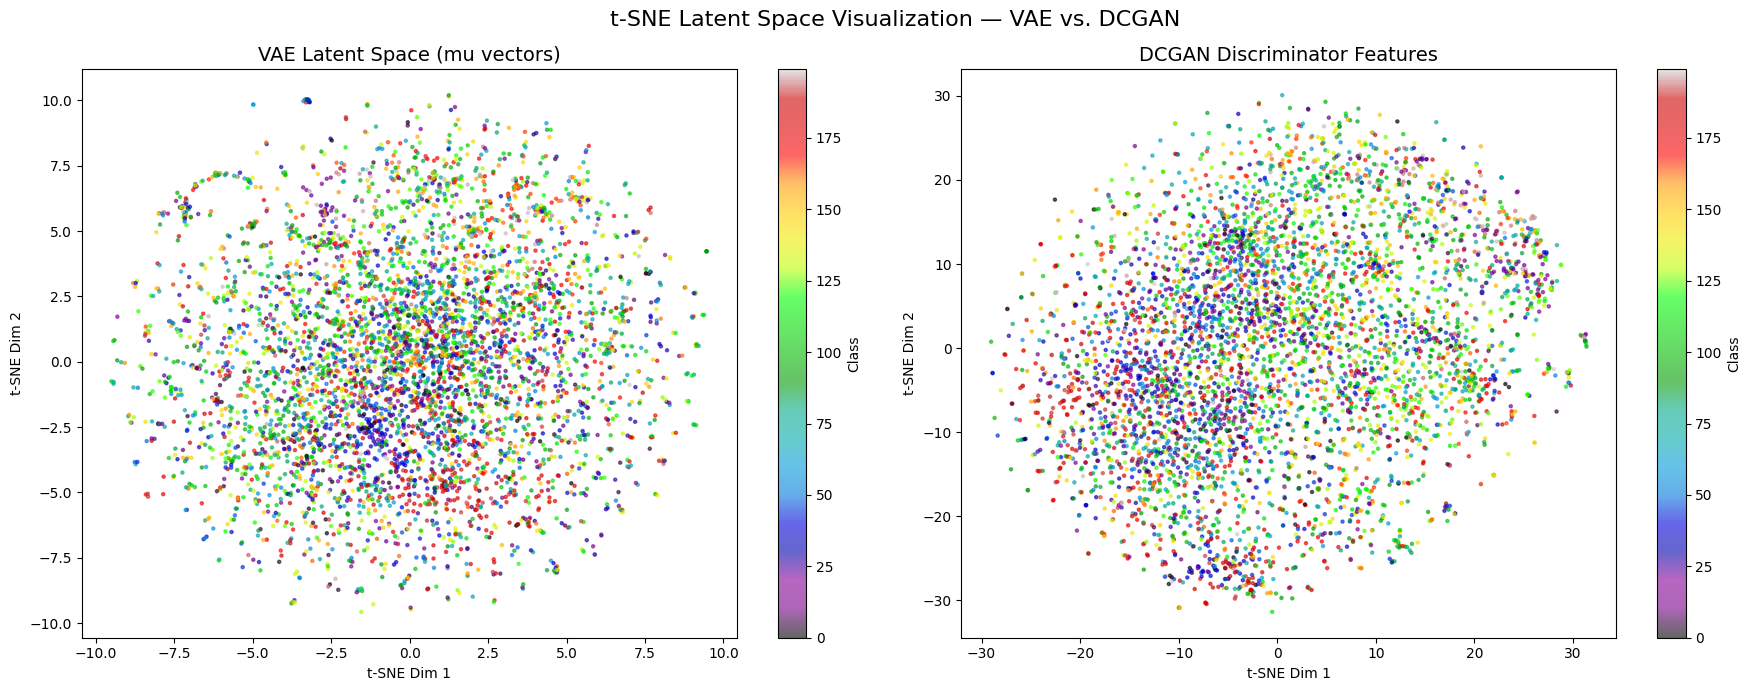

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

scatter1 = axes[0].scatter(mu_2d[:, 0], mu_2d[:, 1],
                           c=labels_tsne_vae, cmap='nipy_spectral', s=5, alpha=0.6)
axes[0].set_title('VAE Latent Space (mu vectors)', fontsize=14)
axes[0].set_xlabel('t-SNE Dim 1')
axes[0].set_ylabel('t-SNE Dim 2')
plt.colorbar(scatter1, ax=axes[0], label='Class')

scatter2 = axes[1].scatter(feat_2d[:, 0], feat_2d[:, 1],
                           c=labels_tsne_gan, cmap='nipy_spectral', s=5, alpha=0.6)
axes[1].set_title('DCGAN Discriminator Features', fontsize=14)
axes[1].set_xlabel('t-SNE Dim 1')
axes[1].set_ylabel('t-SNE Dim 2')
plt.colorbar(scatter2, ax=axes[1], label='Class')

plt.suptitle('t-SNE Latent Space Visualization \u2014 VAE vs. DCGAN', fontsize=16)
plt.tight_layout()
plt.show()